# Transit extraction

Kind of a crazy hail mary idea here, considering there are about two days left in the competition. But, I have a plan to introduce more data diversity, better isolate the plane's atmospheric signal, and make the inputs to the model smaller.

This is a different strategy than the time point based sampling of the extracted frames I have been using. For it to work, I need to start with the planet frames (wavelengths, time points). So in theory, we could add it to the data preprocessing pipeline as an additional, maybe optional step.

Steps are, per-planet:

1. Identify transit and non-transit captures using the total signal
2. Split the planet image into transit and non-transit
3. Create n versions of each transit capture spectrum by subtracting each non-transit capture spectrum

On additional wrinkle here on the topic of spectroscopy in general - I expect anything interesting in the planet's atmosphere to absorb IR, so we are really looking for stuff that's missing from the star's spectrum during the transit. But I don't know if that is what is in the given ground truth spectra. It could be the planet's absorbance spectrum - i.e. strongly absorbed wavelengths show up as peaks, or it could be the transmitted spectrum, with the star's emission profile removed - i.g. strongly absorbed wavelengths show up as valleys.

If we had more time, we could make some test submission to try out both strategies - but at this point, we are out of time. Need to just show a neural net the data and let it sort out the relationships.

## Notebook set up

In [1]:
# Set notebook root to project root
from helper_functions import set_project_root

set_project_root()

# Standard library imports
from pathlib import Path
from random import shuffle

# Third party imports
import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

# Local imports
from ariel_data_preprocessing.utils import load_masked_frames
import configuration as config

# Make sure the figures directory exists
figures_dir = f'{config.FIGURES_DIRECTORY}/signal_extraction'
Path(figures_dir).mkdir(parents=True, exist_ok=True)

Working directory: /mnt/arkk/kaggle/ariel-data-challenge


## 1. Load corrected/extracted data for a sample planet

In [2]:
# Load corrected/extracted data for a sample planet
with h5py.File(f'{config.PROCESSED_DATA_DIRECTORY}/train.h5', 'r') as hdf:
    signal, planet_id = load_masked_frames(hdf, planet='random', return_id=True)

## 2. Find transit start and end indices

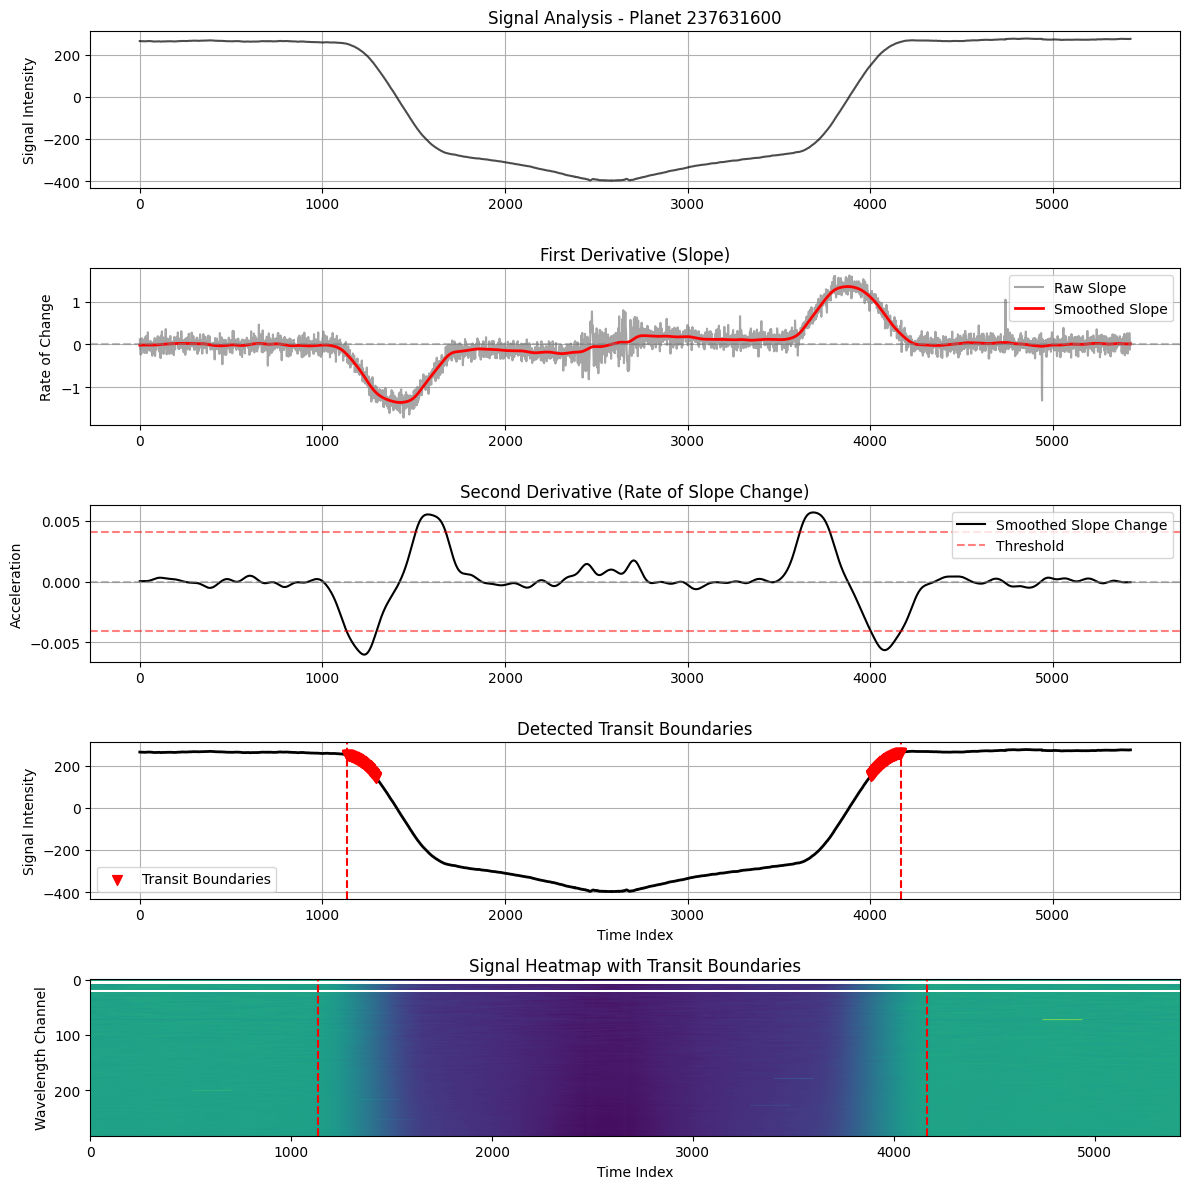

In [3]:
# Sum the signal across all wavelength channels to get a 1D time series
total_signal = np.sum(signal, axis=1)

# Calculate first derivative (slope)
slope = np.gradient(total_signal)

# Smooth the first derivative before calculating second derivative
smoothed_slope = gaussian_filter1d(slope, sigma=30)

# Calculate second derivative (rate of slope change) using smoothed slope
slope_change = np.gradient(smoothed_slope)

smoothed_slope_change = gaussian_filter1d(slope_change, sigma=30)

# Find regions where slope is changing most quickly
slope_change_threshold = np.std(smoothed_slope_change) * 2

# Find steep negative slope changes (rapid deceleration - transit start candidates)
transit_boundaries = np.where(smoothed_slope_change < -slope_change_threshold)[0]

# Plot comprehensive analysis
fig, axes = plt.subplots(5, 1, figsize=(12, 12))

# Raw signal
axes[0].plot(total_signal, color='black', alpha=0.7)
axes[0].set_title(f'Signal Analysis - Planet {planet_id}')
axes[0].set_ylabel('Signal Intensity')
axes[0].grid(True)

# First derivative (slope) - both raw and smoothed
axes[1].plot(slope, label='Raw Slope', alpha=0.7, color='grey')
axes[1].plot(smoothed_slope, label='Smoothed Slope', linewidth=2, color='red')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('First Derivative (Slope)')
axes[1].set_ylabel('Rate of Change')
axes[1].legend()
axes[1].grid(True)

# Second derivative (slope change)
axes[2].plot(smoothed_slope_change, label='Smoothed Slope Change', color='black')
axes[2].axhline(y=slope_change_threshold, color='red', linestyle='--', alpha=0.5, label='Threshold')
axes[2].axhline(y=-slope_change_threshold, color='red', linestyle='--', alpha=0.5)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Second Derivative (Rate of Slope Change)')
axes[2].set_ylabel('Acceleration')
axes[2].legend()
axes[2].grid(True)

# Transit boundaries overlaid on original signal
axes[3].plot(total_signal, color='black', linewidth=2)
axes[3].scatter(transit_boundaries, total_signal[transit_boundaries], 
               color='red', s=50, marker='v', label='Transit Boundaries', zorder=5)
axes[3].axvline(x=transit_boundaries[0], color='red', linestyle='--')
axes[3].axvline(x=transit_boundaries[-1], color='red', linestyle='--')
axes[3].set_title('Detected Transit Boundaries')
axes[3].set_xlabel('Time Index')
axes[3].set_ylabel('Signal Intensity')
axes[3].legend()
axes[3].grid(True)

# Transit boundaries overlaid on signal heatmap
im = axes[4].imshow(signal.T, aspect='auto', cmap='viridis')
axes[4].axvline(x=transit_boundaries[0], color='red', linestyle='--')
axes[4].axvline(x=transit_boundaries[-1], color='red', linestyle='--')
axes[4].set_title('Signal Heatmap with Transit Boundaries')
axes[4].set_xlabel('Time Index')
axes[4].set_ylabel('Wavelength Channel')
axes[4].grid(False)

fig.tight_layout()

fig.savefig(
    f'{figures_dir}/02.8.1-transit_boundary_detection.jpg',
    dpi=config.STD_FIG_DPI,
    bbox_inches='tight'
)